# api-ops-full — 全量专轨

**环境**：Jupyter 内核选 **`med-rag-verify`**（与 01–11 相同）。  
F0 建库只用标准库 `sqlite3` + 本仓库代码，**不需要** Ollama / Chroma / GPU。  
若缺包：在阶段 12 目录执行 `pip install -r requirements.txt`（主要补 `python-dotenv`）。

- **F0**：构建 / 续跑 `Dataset/documents/full/documents_full.sqlite`（进度可视化）
- **F1+**：全量仿真（阶段 5；需 `full/manifest_full.json` → `status=completed`）

与样本分目录：`documents/sample/` ≠ `documents/full/`。

也可终端后台（先 `conda activate med-rag-verify`）：
```text
python scripts/build_documents_index.py --mode full --batch-size 50000
python scripts/build_documents_index.py --mode full --status
```


## F0 — 环境隔离 + 全量目录自检

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

# 避免 Path.resolve() / 上游 src 残留 → WinError 6714
NOTEBOOK_DIR = Path(os.path.abspath(os.getcwd()))
STAGE12 = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
REPO = STAGE12.parent

# 清掉 Jupyter 内核里残留的 05–11 路径（否则任意 import 扫目录就会 6714）
_MARKERS = (
    "05 检索系统开发第一部分",
    "06 检索系统开发第二部分",
    "07 生成模块与提示词工程第一部分",
    "08 生成模块与提示词工程第二部分",
    "09 生成答案评估",
    "10 强约束规则开发与幻觉抑制",
    "11 服务化与接口开发第一部分",
)
sys.path[:] = [p for p in sys.path if not any(m in p.replace("/", "\\") for m in _MARKERS)]

for name in ("config", "bootstrap", "resources", "app", "dataset_paths"):
    sys.modules.pop(name, None)
for key in list(sys.modules):
    if key == "app" or key.startswith("app."):
        sys.modules.pop(key, None)

for p in (str(REPO), str(STAGE12)):
    while p in sys.path:
        sys.path.remove(p)
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(STAGE12))

# F0 只需建库 / 读 status，不要 bootstrap 05–10、不要 bridge11
from app.documents_index import (
    build_documents_index,
    manifest_path_for,
    mode_dir_for,
    progress_path_for,
    sqlite_path_for,
    status,
)
from dataset_paths import DOCUMENTS_FULL_DIR, DOCUMENTS_FULL_SQLITE, SLIM_JSONL

print("slim", os.path.isfile(str(SLIM_JSONL)), SLIM_JSONL)
print("full_dir", DOCUMENTS_FULL_DIR)
print("sqlite", DOCUMENTS_FULL_SQLITE)
print("progress", progress_path_for("full"))
print("manifest", manifest_path_for("full"))
print(json.dumps(status("full"), ensure_ascii=False, indent=2))


slim True D:\谷歌\Dataset\processed\oa_comm_slim.jsonl
full_dir D:\谷歌\Dataset\documents\full
sqlite D:\谷歌\Dataset\documents\full\documents_full.sqlite
progress D:\谷歌\Dataset\documents\full\progress_full.json
manifest D:\谷歌\Dataset\documents\full\manifest_full.json
{
  "mode": "full",
  "sqlite": "D:\\谷歌\\Dataset\\documents\\full\\documents_full.sqlite",
  "sqlite_exists": true,
  "row_count": 4557627,
  "progress": {
    "format": "documents_index_v1",
    "mode": "full",
    "schema_version": 1,
    "batch_size": 50000,
    "processed_lines": 4557627,
    "valid_rows": 4557627,
    "last_pmcid": "PMC12823268",
    "matched_sample": null,
    "sample_target": null,
    "updated_at": "2026-07-27T08:16:08Z",
    "source_path": "D:\\谷歌\\Dataset\\processed\\oa_comm_slim.jsonl",
    "source_exists": true,
    "source_size_bytes": 8896642264,
    "source_mtime": 1779813364.2908616,
    "phase": "completed",
    "status": "completed",
    "row_count": 4557627
  },
  "manifest": {
    "format": 

## F0 — 启动 / 续跑全量构建

将 `RUN_FULL_BUILD = True` 后运行。默认 `RESUME=True`（中断可续）。
产物全部写入 `Dataset/documents/full/`。

In [ ]:
# >>> 创建全量索引：改为 True 后运行本格 <<<
RUN_FULL_BUILD = False
BATCH_SIZE = 50_000
RESUME = True  # 中断后续跑同一格即可；强制从头则 False

mode_dir_for("full").mkdir(parents=True, exist_ok=True)

t0 = time.perf_counter()
history = []

def _cb(p):
    history.append(dict(p))
    lines = p.get("processed_lines") or 0
    rows = p.get("valid_rows") or 0
    print(
        f"[{p.get('phase')}] lines={lines:,} rows={rows:,} "
        f"last={p.get('last_pmcid')} elapsed={time.perf_counter()-t0:.1f}s",
        flush=True,
    )

if RUN_FULL_BUILD:
    print("building →", sqlite_path_for("full"))
    manifest = build_documents_index(
        "full",
        batch_size=BATCH_SIZE,
        resume=RESUME,
        progress_cb=_cb,
    )
    print(json.dumps(manifest, ensure_ascii=False, indent=2))
    assert manifest.get("status") == "completed"
    print("F0 PASS — documents/full ready")
else:
    print("RUN_FULL_BUILD=False — 仅展示 status")
    print(json.dumps(status("full"), ensure_ascii=False, indent=2))

building → D:\谷歌\Dataset\documents\full\documents_full.sqlite
[writing] lines=50,000 rows=50,000 last=PMC2377171 elapsed=1.1s
[writing] lines=100,000 rows=100,000 last=PMC2830950 elapsed=2.3s
[writing] lines=150,000 rows=150,000 last=PMC3044096 elapsed=3.4s
[writing] lines=200,000 rows=200,000 last=PMC3250972 elapsed=4.5s
[writing] lines=250,000 rows=250,000 last=PMC3435393 elapsed=5.7s
[writing] lines=300,000 rows=300,000 last=PMC3591258 elapsed=6.9s
[writing] lines=350,000 rows=350,000 last=PMC3751602 elapsed=8.2s
[writing] lines=400,000 rows=400,000 last=PMC3907692 elapsed=9.5s
[writing] lines=450,000 rows=450,000 last=PMC4053804 elapsed=10.7s
[writing] lines=500,000 rows=500,000 last=PMC4214501 elapsed=12.0s
[writing] lines=550,000 rows=550,000 last=PMC4363399 elapsed=13.4s
[writing] lines=600,000 rows=600,000 last=PMC4496389 elapsed=14.7s
[writing] lines=650,000 rows=650,000 last=PMC4632024 elapsed=16.1s
[writing] lines=700,000 rows=700,000 last=PMC4762005 elapsed=17.4s
[writing] 

In [3]:
# 可选：另一终端 CLI 构建时，在此轮询 progress_full.json
POLL = False
POLL_ROUNDS = 60
POLL_SEC = 10

if POLL:
    try:
        from IPython.display import clear_output
    except ImportError:
        clear_output = None
    for i in range(POLL_ROUNDS):
        st = status("full")
        if clear_output:
            clear_output(wait=True)
        print(f"poll {i+1}/{POLL_ROUNDS}")
        print(json.dumps(st, ensure_ascii=False, indent=2))
        if st.get("completed"):
            print("completed")
            break
        time.sleep(POLL_SEC)
else:
    print("POLL=False — 需要监视 CLI 进度时改为 True")
    print(json.dumps(status("full"), ensure_ascii=False, indent=2))

POLL=False — 需要监视 CLI 进度时改为 True
{
  "mode": "full",
  "sqlite": "D:\\谷歌\\Dataset\\documents\\full\\documents_full.sqlite",
  "sqlite_exists": true,
  "row_count": 4557627,
  "progress": {
    "format": "documents_index_v1",
    "mode": "full",
    "schema_version": 1,
    "batch_size": 50000,
    "processed_lines": 4557627,
    "valid_rows": 4557627,
    "last_pmcid": "PMC12823268",
    "matched_sample": null,
    "sample_target": null,
    "updated_at": "2026-07-27T08:16:08Z",
    "source_path": "D:\\谷歌\\Dataset\\processed\\oa_comm_slim.jsonl",
    "source_exists": true,
    "source_size_bytes": 8896642264,
    "source_mtime": 1779813364.2908616,
    "phase": "completed",
    "status": "completed",
    "row_count": 4557627
  },
  "manifest": {
    "format": "documents_index_v1",
    "status": "completed",
    "mode": "full",
    "schema_version": 1,
    "batch_size": 50000,
    "row_count": 4557627,
    "valid_rows_written": 4557627,
    "processed_lines": 4557627,
    "elapsed_sec":

## F1+ — 全量仿真（阶段 5）

待 `Dataset/documents/full/manifest_full.json` 的 `status=completed`，且阶段 4 完成后补齐。

In [2]:
# F1-A — 环境自检（子进程，避开 Jupyter WinError 6714）
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath(os.getcwd()))
STAGE12 = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
REPO = STAGE12.parent  # noqa: F841

cmd = [sys.executable, str(STAGE12 / "scripts" / "probe_full_ops_env.py")]
print("running:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=str(STAGE12), capture_output=True, text=True)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr[-2000:] if len(proc.stderr) > 2000 else proc.stderr)
assert proc.returncode == 0, f"F1-A probe failed rc={proc.returncode}"
payload = json.loads(proc.stdout)
assert payload.get("ready"), payload
REPORT_DIR = STAGE12 / "outputs" / "reports"
print("F1-A PASS")


running: c:\Users\10138\miniconda3\envs\med-rag-verify\python.exe d:\谷歌\12 服务化与接口开发第二部分\scripts\probe_full_ops_env.py
{
  "env": {
    "MED_RAG_RETRIEVAL_MODE": "full",
    "STAGE12_RETRIEVAL_MODE": "full",
    "STAGE11_RETRIEVAL_MODE": "full",
    "STAGE12_DOCUMENTS_MODE": "full",
    "STAGE12_PIPELINE_BACKEND": "constrained10",
    "STAGE12_LOG_DIR": "D:\\谷歌\\12 服务化与接口开发第二部分\\outputs\\reports"
  },
  "ready": true,
  "documents_full_ok": true,
  "documents_full": {
    "completed": true,
    "row_count": 4557627,
    "sqlite_exists": true
  },
  "chroma_full_exists": true,
  "bm25_manifest_ok": true,
  "bm25_total_chunks": 6107296,
  "ollama_ok": true,
  "model_present": true,
  "hints": [
    "Set RUN_LIVE_FULL=True only after ready=True",
    "Expect multi-minute cold start (Chroma+BM25+reranker+Ollama)",
    "Keep a single RagService singleton — do not from_mode(full) per request",
    "Require documents/full manifest status=completed",
    "Set MED_RAG_RETRIEVAL_MODE=full and STA

In [3]:
# F1-B — live 全量仿真
# Jupyter 内直接 import 跑 live 易触发 WinError 6714；默认用子进程调 CLI（与终端成功路径一致）。

RUN_LIVE_FULL = True
USE_SUBPROCESS = True  # False 才走进程内 run_full_ops_smoke（不推荐 on Win 中文路径）

if not RUN_LIVE_FULL:
    print("RUN_LIVE_FULL=False — skip live.")
    print("Or CLI: conda run -n med-rag-verify python scripts/run_full_ops_smoke.py")
elif USE_SUBPROCESS:
    import subprocess
    import sys

    cmd = [sys.executable, str(STAGE12 / "scripts" / "run_full_ops_smoke.py")]
    print("running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(STAGE12))
    assert proc.returncode == 0, f"full ops smoke failed rc={proc.returncode}"
    print("F1-B PASS — see outputs/reports/full_ops_smoke.json")
else:
    from app.full_ops_smoke import run_full_ops_smoke

    record = run_full_ops_smoke(
        query="metformin cardiovascular effects",
        follow_up="follow-up: what is the evidence strength?",
        top_k=5,
        run_stream=True,
        report_dir=REPORT_DIR,
    )
    print(json.dumps({
        "ok": record.get("ok"),
        "error": record.get("error"),
        "warmup_sec": record.get("warmup_sec"),
        "checks": record.get("checks"),
        "artifacts": record.get("artifacts"),
    }, ensure_ascii=False, indent=2))
    if record.get("qa_turn1"):
        s = record["qa_turn1"]
        print("qa1", s.get("wall_clock_sec"), "s", "pmcids", s.get("pmcids"))
    assert record.get("ok"), record.get("error") or record.get("checks")
    print("F1-B PASS — see outputs/reports/full_ops_smoke.json")


running: c:\Users\10138\miniconda3\envs\med-rag-verify\python.exe d:\谷歌\12 服务化与接口开发第二部分\scripts\run_full_ops_smoke.py
F1-B PASS — see outputs/reports/full_ops_smoke.json


ok= True warmup= 1.79
checks {
  "qa_two_turns": true,
  "session_id_stable": true,
  "stream_pseudo": true,
  "stats_full_scale": true,
  "turn_count_2": true,
  "documents_full": true,
  "stats_qa_grew": true
}
chunk_count 6107296 document_count 4557627
session turn_count 3
documents list_total 4557627 get_ok True
overview_png D:\谷歌\12 服务化与接口开发第二部分\outputs\reports\full_ops_smoke_overview.png


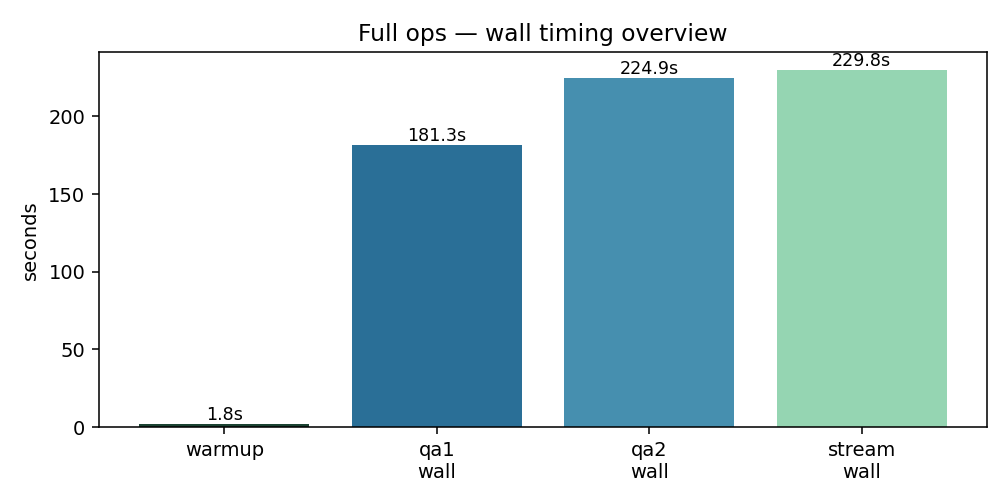

stage_times_png D:\谷歌\12 服务化与接口开发第二部分\outputs\reports\full_ops_smoke_stage_times.png


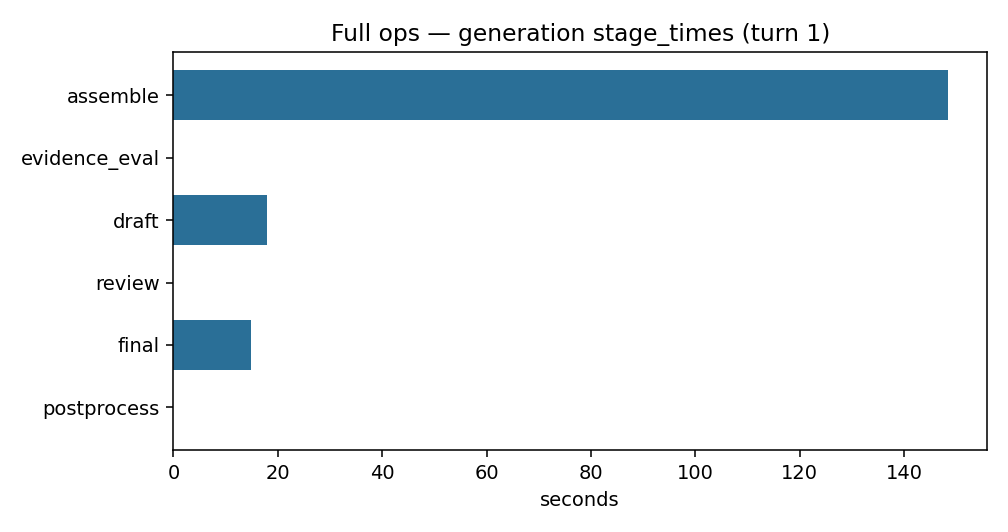

constraints_png D:\谷歌\12 服务化与接口开发第二部分\outputs\reports\full_ops_smoke_constraints.png


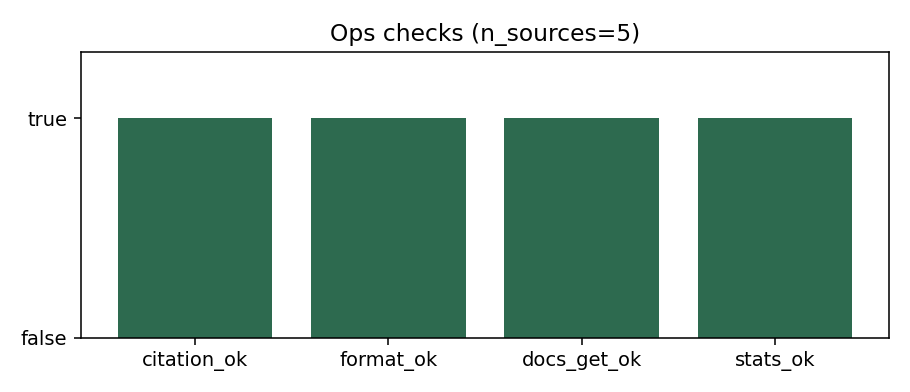

sse_timeline_png D:\谷歌\12 服务化与接口开发第二部分\outputs\reports\full_ops_smoke_sse_timeline.png


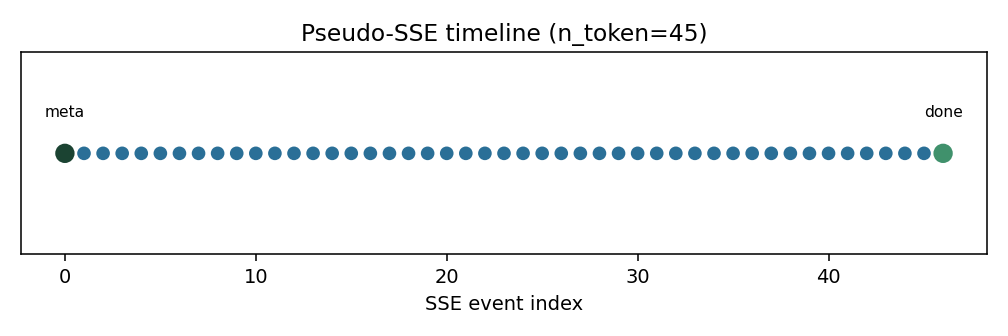

qa_log D:\谷歌\12 服务化与接口开发第二部分\outputs\reports\qa_calls_full_ops.jsonl


In [4]:
# F1-C — 展示已有报告（F1-B 或 CLI 跑过后）
from IPython.display import Image, display

report_json = REPORT_DIR / "full_ops_smoke.json"
if not report_json.is_file():
    print("no report yet — run F1-B with RUN_LIVE_FULL=True or CLI run_full_ops_smoke.py")
else:
    rec = json.loads(report_json.read_text(encoding="utf-8"))
    print("ok=", rec.get("ok"), "warmup=", rec.get("warmup_sec"))
    print("checks", json.dumps(rec.get("checks"), ensure_ascii=False, indent=2))
    idx = (rec.get("stats") or {}).get("index") or {}
    print("chunk_count", idx.get("chunk_count"), "document_count", idx.get("document_count"))
    print("session turn_count", (rec.get("session_detail") or {}).get("turn_count"))
    docs = rec.get("documents") or {}
    print("documents list_total", docs.get("list_total"), "get_ok", docs.get("get_ok"))
    arts = rec.get("artifacts") or {}
    for key in ("overview_png", "stage_times_png", "constraints_png", "sse_timeline_png"):
        p = arts.get(key)
        if p and Path(p).is_file():
            print(key, p)
            display(Image(filename=p))
    print("qa_log", arts.get("qa_log"))
